In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn_custom_mlp import CustomMLPClassifier

In [2]:
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=10, scoring='accuracy', n_jobs=8, train_sizes=np.linspace(0.1, 1.0, 25))
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    plt.subplots(1, figsize=(6,4))
    plt.plot(train_sizes, train_mean, color="red",  label="Training score")
    plt.plot(train_sizes, val_mean, color="blue", label="Cross-validation score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="red", alpha=.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="blue", alpha=.2)

    plt.title("Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

dimensions de X: (100, 2)
dimensions de y: (100,)


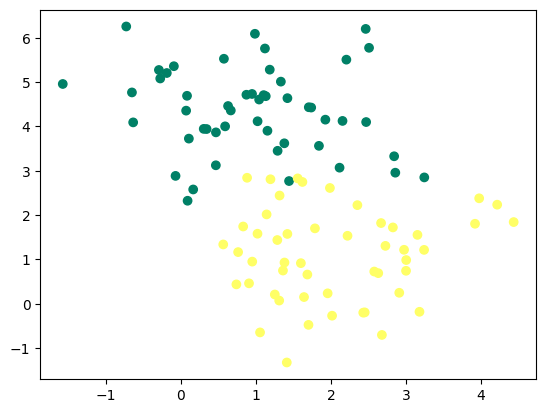

In [3]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
# X, y = make_circles(n_samples=100, noise=0.1, factor=0.3, random_state=0)

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [5]:
print(f"X: {type(X_train)} of shape {X_train.shape}")
print(f"y: {type(y_train)} of shape {y_train.shape}")

X: <class 'numpy.ndarray'> of shape (75, 2)
y: <class 'numpy.ndarray'> of shape (75,)


In [6]:
model = CustomMLPClassifier(hidden_layers=[1])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [7]:
y_test.shape

(25,)

In [8]:
y_pred.shape

(25,)

In [9]:
y_pred.flatten().shape

(25,)

In [10]:
accuracy_score(y_test, y_pred)

1.0

In [11]:
model.score(X_test, y_test)

1.0

In [12]:
# plot_learning_curve(model, X_train, y_train)

In [13]:
# layers_list = [[1], [1, 1], [1, 1, 1], [8], [8, 8], [8, 8, 8], [16], [16, 16], [16, 16, 16], [32], [32, 32], [32, 32, 32], [128, 128, 128], [256, 256, 256], [64, 64, 64, 64, 64, 64]]
# layers_list = [[1], [1, 1], [1, 1, 1], [8], [8, 8], [8, 8, 8], [16], [16, 16], [16, 16, 16], [32], [32, 32], [32, 32, 32]]
#layers_list = [[2], [2, 2], [2, 2, 2], [8], [8, 8], [8, 8, 8], [16], [16, 16], [32], [32, 32]]
len(layers_list)

layers_list = [[2], [2, 2], [2, 2, 2], [8], [8, 8]]


10

LAYERS [2] - final loss: 0.2004695155792659 ; final acc: 0.93


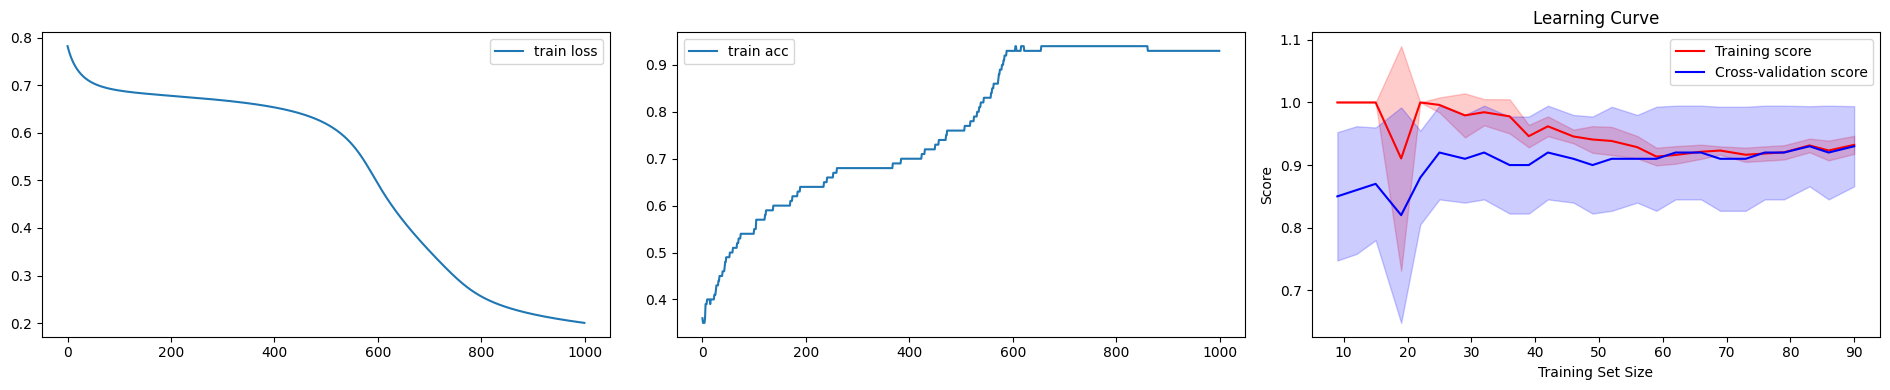

LAYERS [2, 2] - final loss: 0.18817380986545815 ; final acc: 0.93


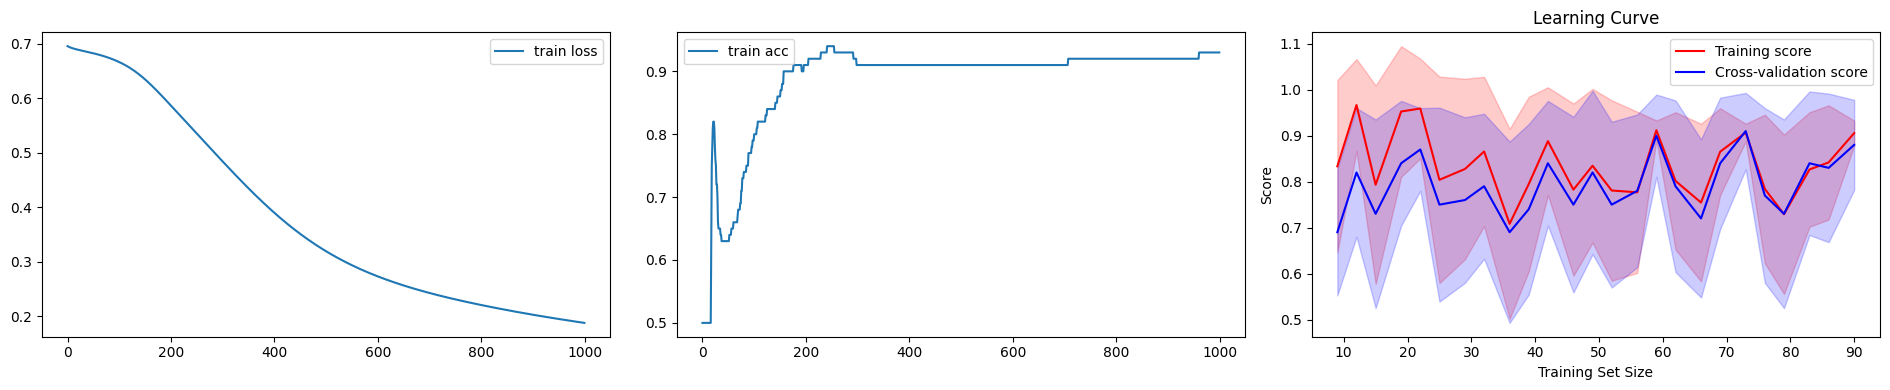

LAYERS [2, 2, 2] - final loss: 0.6905310510431534 ; final acc: 0.79


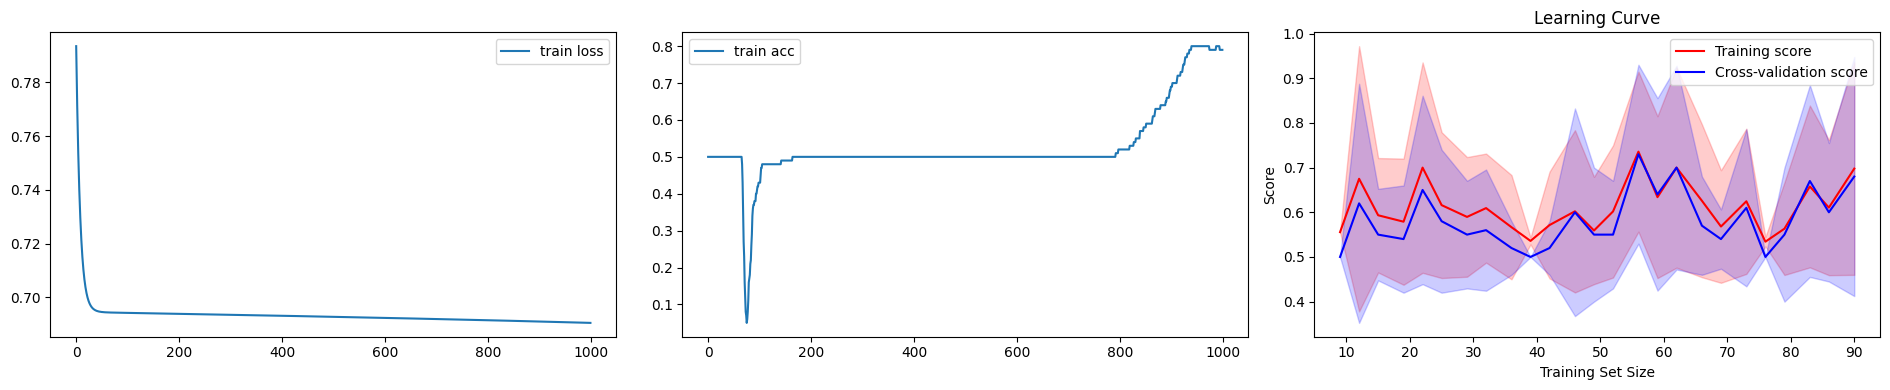

LAYERS [8] - final loss: 0.13777935009266062 ; final acc: 0.93


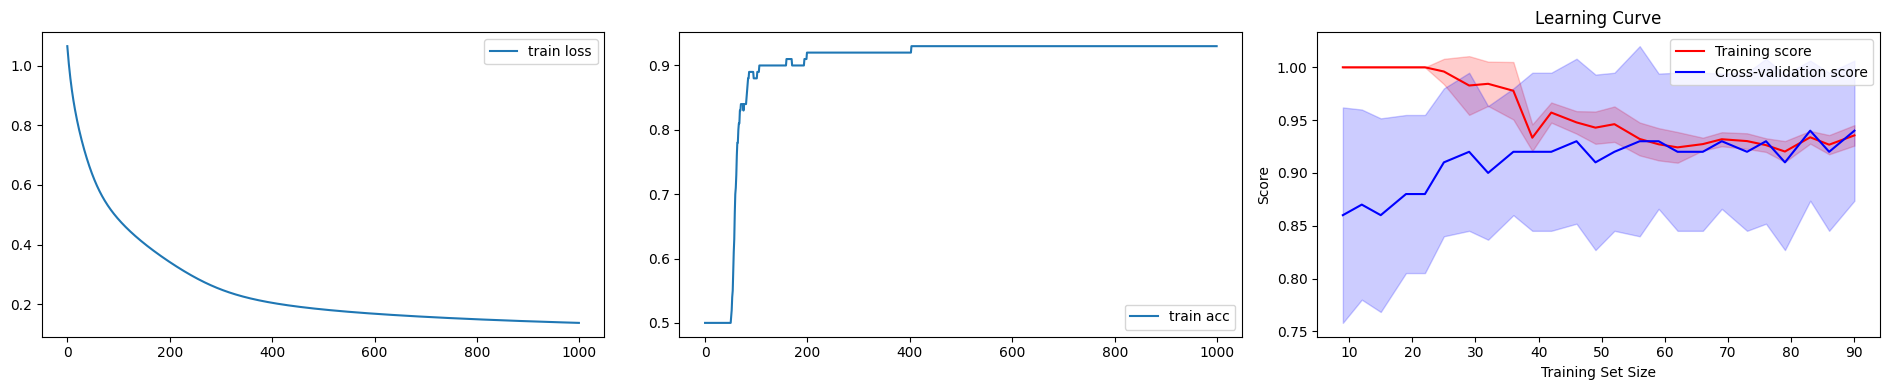

LAYERS [8, 8] - final loss: 0.17392576908155527 ; final acc: 0.93


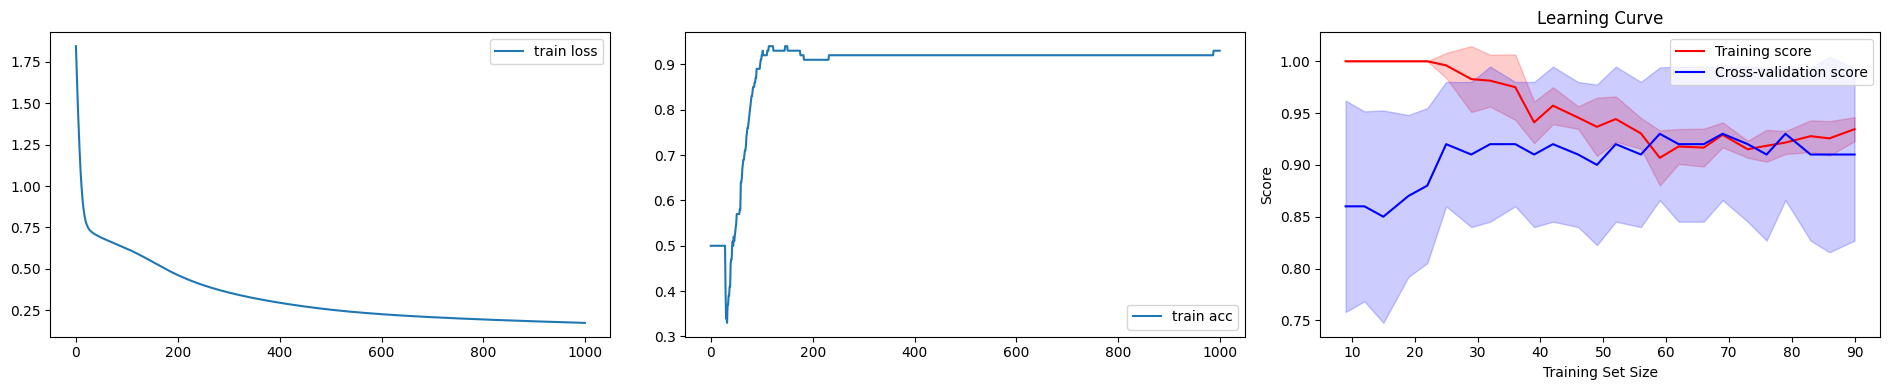

LAYERS [8, 8, 8] - final loss: 0.27350112255657477 ; final acc: 0.88


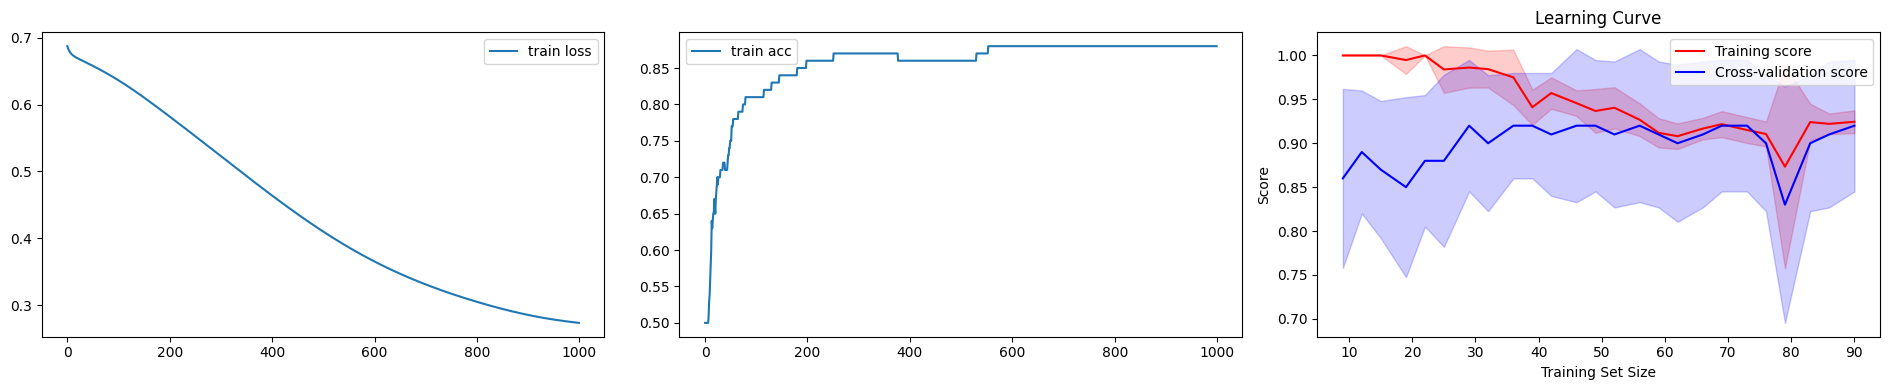

LAYERS [16] - final loss: 0.12024616899479865 ; final acc: 0.94


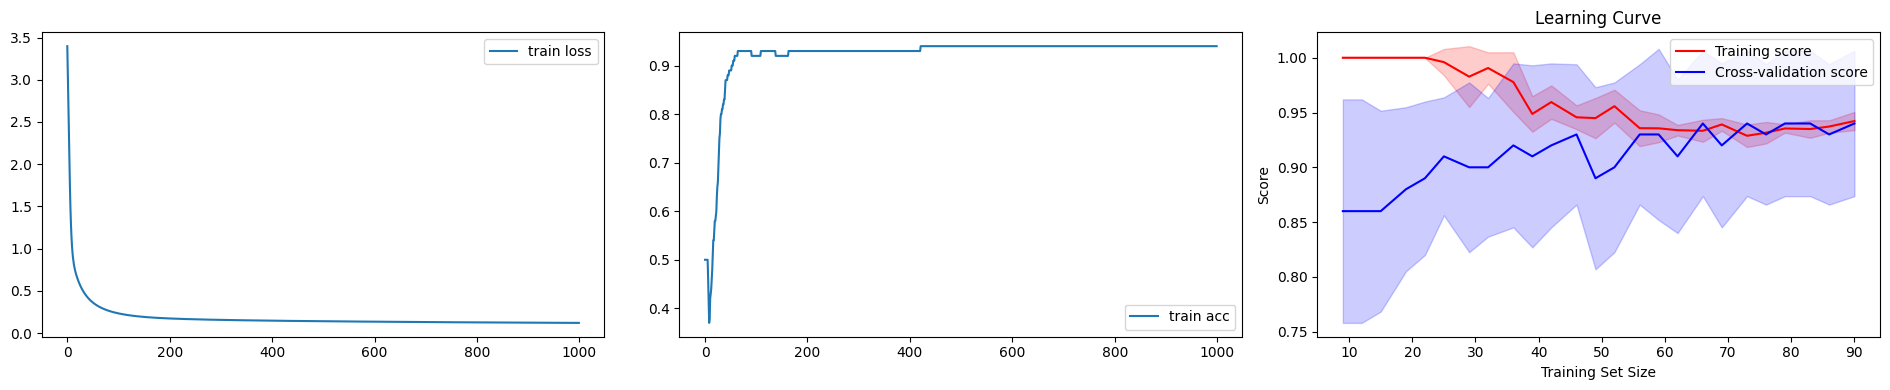

LAYERS [16, 16] - final loss: 0.13995862201231357 ; final acc: 0.94


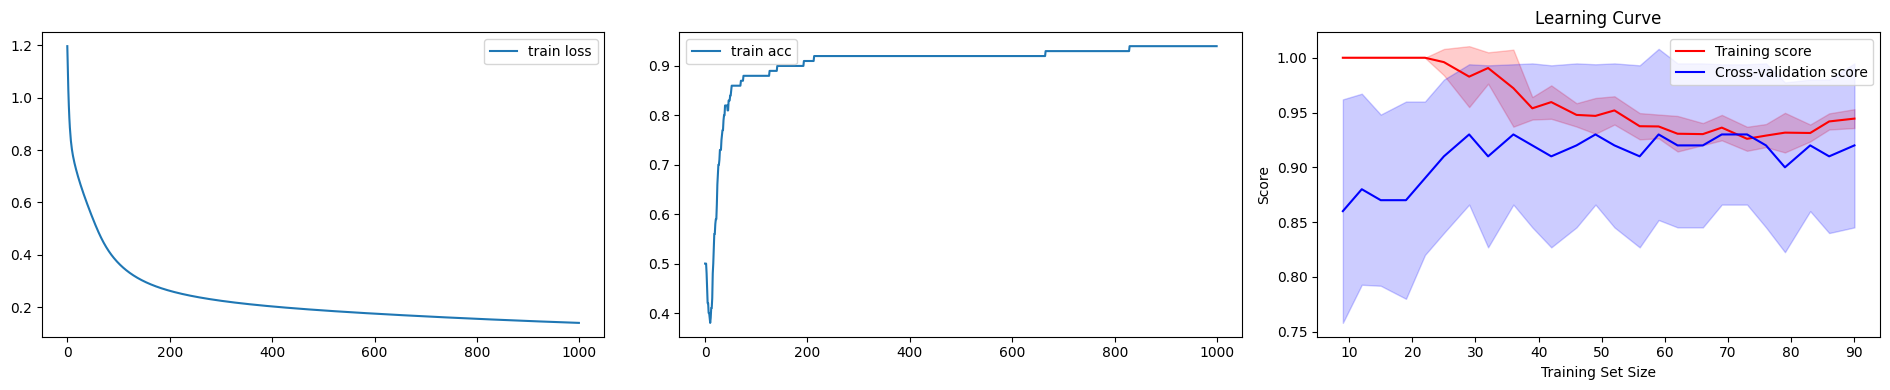

LAYERS [32] - final loss: 0.12498246877834733 ; final acc: 0.94


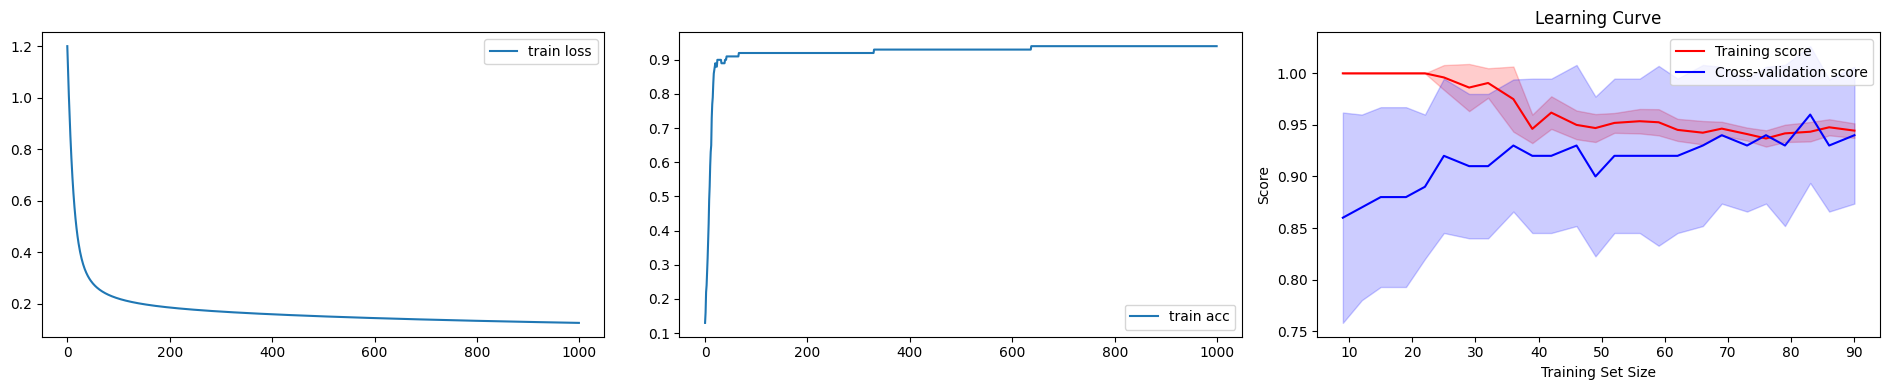

LAYERS [32, 32] - final loss: 0.08422887119131842 ; final acc: 0.96


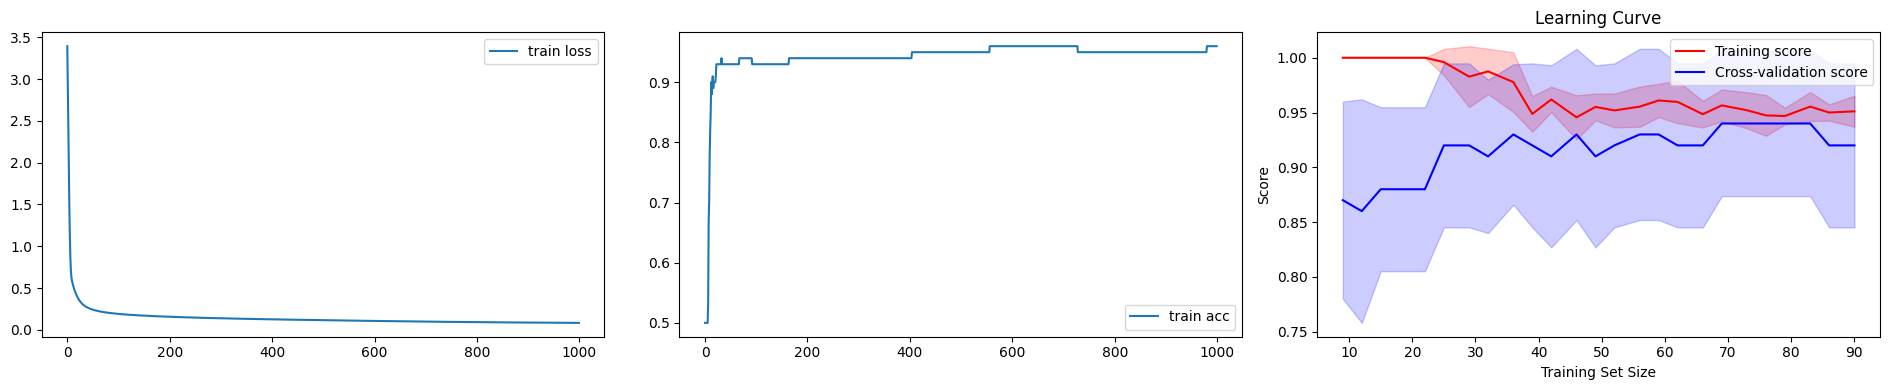

In [14]:

for i, layers in enumerate(layers_list, start=1):
    model = CustomMLPClassifier(layers)
    train_loss, train_acc = model.fit(X, y, return_fit_report=True)

    print(f"LAYERS {str(layers)} - final loss: {train_loss[-1]} ; final acc: {train_acc[-1]}")

    plt.figure(figsize=(19, 4))
    plt.subplot(1, 3, 1)
    plt.plot(train_loss, label='train loss')
    plt.legend()
    plt.subplot(1, 3, 2)
    plt.plot(train_acc, label='train acc')
    plt.legend()
    train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=10, scoring='accuracy', n_jobs=8, train_sizes=np.linspace(0.1, 1.0, 25))
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)

    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    plt.subplot(1, 3, 3)
    plt.plot(train_sizes, train_mean, color="red",  label="Training score")
    plt.plot(train_sizes, val_mean, color="blue", label="Cross-validation score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="red", alpha=.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color="blue", alpha=.2)

    plt.title("Learning Curve")
    plt.xlabel("Training Set Size")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()